In [1]:
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import numpy as np
import dataloader as dl

Number of training samples: 60000
Shape of x_train: torch.Size([36000, 28, 28]), y_train: torch.Size([36000])
Shape of x_val: torch.Size([12000, 28, 28]), y_val: torch.Size([12000])
Shape of x_test: torch.Size([12000, 28, 28]), y_test: torch.Size([12000])
After filtering for classes 0 and 1:
Shape of x_train_filtered: torch.Size([7599, 784]), y_train_filtered: torch.Size([7599])
Shape of x_val_filtered: torch.Size([2532, 784]), y_val_filtered: torch.Size([2532])
Shape of x_test_filtered: torch.Size([2534, 784]), y_test_filtered: torch.Size([2534])
---------
Shape of x_train: torch.Size([36000, 784]), y_train: torch.Size([36000])
Shape of x_val: torch.Size([12000, 784]), y_val: torch.Size([12000])
Shape of x_test: torch.Size([12000, 784]), y_test: torch.Size([12000])


Configration

In [2]:
Learning_rate = 0.01
no_epochs = 30

# Logistic Regression Implementation

In [3]:
torch.manual_seed(42)

class Logistic_Regression_from_scratch():
    def __init__(self):
        self.w = torch.randn(28*28, requires_grad=True)
        
        self.b = torch.zeros(1, requires_grad=True)
        
        self.validation_losses = []
        self.training_losses = []
        self.validation_accuracies = []
        self.training_accuracies = []
        
    def sigmoid(self, z):
        return 1 / (1 + torch.exp(-z))

    def bce_loss(self,y_true, y_pred):
        epsilon = 1e-7
        loss = - (y_true * torch.log(y_pred + epsilon) + (1 - y_true) * torch.log(1 - y_pred + epsilon))
        return torch.mean(loss)
    
    def forward_pass(self, x):
        output =  x @ self.w + self.b
        y_pred = self.sigmoid(output)
        return y_pred
    
    def train(self, learning_rate, no_epochs, train_loader, val_loader):
        for epoch in range(no_epochs):
            train_loss = 0
            val_losses = 0
            train_accuracy = 0
            val_accuracy = 0
            
            for data, target in train_loader:
                target = target.float()
                
                y_pred = self.forward_pass(data)
                loss = self.bce_loss(target, y_pred)
                

                train_accuracy += self.calculate_accuracy(target, y_pred)

                train_loss += loss.item()
                
                loss.backward()
                
                with torch.no_grad():
                    self.w -= learning_rate * self.w.grad
                    self.b  -= learning_rate * self.b.grad
                    
                    self.w.grad.zero_()
                    self.b.grad.zero_()

            
            
            with torch.no_grad():
                for val_data, val_target in val_loader:
                    val_target = val_target.float()
                    val_pred = self.forward_pass(val_data)
                    
                    val_accuracy += self.calculate_accuracy(val_target, val_pred)
                    
                    val_loss = self.bce_loss(val_target, val_pred)
                    val_losses += val_loss.item()
                    
                    
            self.training_accuracies.append(train_accuracy / len(train_loader))
            self.validation_accuracies.append(val_accuracy / len(val_loader))
            avg_train_loss = train_loss / len(train_loader)
            avg_val_loss = val_losses / len(val_loader)

            
            self.training_losses.append(avg_train_loss)
            self.validation_losses.append(avg_val_loss)
            
            print(f'Epoch {epoch+1}/{no_epochs}')
            print(f'  Train Loss: {avg_train_loss:.4f} | Train Acc: {self.training_accuracies[epoch]:.2f}%')
            print(f'  Val Loss: {avg_val_loss:.4f} | Val Acc: {self.validation_accuracies[epoch]:.2f}%')
            


    def predict(self, x):
        with torch.no_grad():
            y_pred = self.forward_pass(x)
            predicted_labels = (y_pred > 0.5).float()
        return predicted_labels

    def calculate_accuracy(self, y_true, y_pred):
        predicted_labels = (y_pred > 0.5).float()
        return (predicted_labels == y_true).sum().item() / y_true.shape[0] *100

In [4]:
logisticRegression = Logistic_Regression_from_scratch()

logisticRegression.train(Learning_rate, no_epochs, dl.train_loader_linear_filtered, dl.val_loader_linear_filtered)

Epoch 1/30
  Train Loss: 2.0716 | Train Acc: 56.86%
  Val Loss: 0.6116 | Val Acc: 78.48%
Epoch 2/30
  Train Loss: 0.4199 | Train Acc: 85.72%
  Val Loss: 0.2864 | Val Acc: 91.34%
Epoch 3/30
  Train Loss: 0.2276 | Train Acc: 92.35%
  Val Loss: 0.1834 | Val Acc: 94.57%
Epoch 4/30
  Train Loss: 0.1533 | Train Acc: 95.10%
  Val Loss: 0.1338 | Val Acc: 95.86%
Epoch 5/30
  Train Loss: 0.1147 | Train Acc: 96.44%
  Val Loss: 0.1054 | Val Acc: 96.96%
Epoch 6/30
  Train Loss: 0.0920 | Train Acc: 97.22%
  Val Loss: 0.0875 | Val Acc: 97.50%
Epoch 7/30
  Train Loss: 0.0773 | Train Acc: 97.67%
  Val Loss: 0.0752 | Val Acc: 97.96%
Epoch 8/30
  Train Loss: 0.0666 | Train Acc: 98.02%
  Val Loss: 0.0663 | Val Acc: 98.34%
Epoch 9/30
  Train Loss: 0.0591 | Train Acc: 98.31%
  Val Loss: 0.0595 | Val Acc: 98.53%
Epoch 10/30
  Train Loss: 0.0533 | Train Acc: 98.51%
  Val Loss: 0.0543 | Val Acc: 98.60%
Epoch 11/30
  Train Loss: 0.0485 | Train Acc: 98.63%
  Val Loss: 0.0500 | Val Acc: 98.64%
Epoch 12/30
  Train

## Training vs Validation Loss 

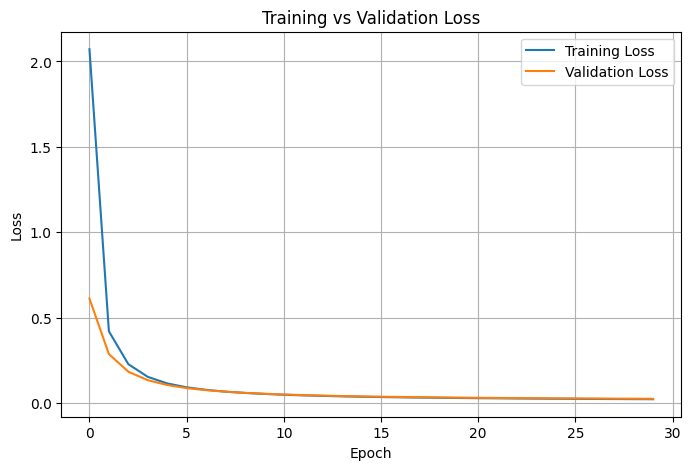

In [5]:
plt.figure(figsize=(8, 5))
plt.plot(logisticRegression.training_losses, label='Training Loss')
plt.plot(logisticRegression.validation_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)
plt.show()


## Target vs value accuracy

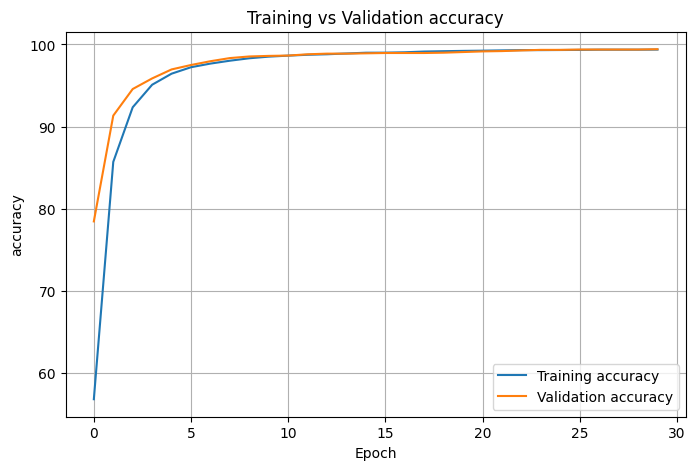

In [6]:
plt.figure(figsize=(8, 5))
plt.plot(logisticRegression.training_accuracies, label='Training accuracy')
plt.plot(logisticRegression.validation_accuracies, label='Validation accuracy')
plt.xlabel('Epoch')
plt.ylabel('accuracy')
plt.title('Training vs Validation accuracy')
plt.legend()
plt.grid(True)
plt.show()

## Test the Model

In [7]:
accuracy = 0
targets = []
predictions = []
with torch.no_grad(): 
    for data, target in dl.test_loader_linear_filtered:
        target = target.float()
        
        prediction = logisticRegression.predict(data)
        accuracy += logisticRegression.calculate_accuracy(target, prediction)
        targets.extend(target.numpy())
        predictions.extend(prediction)
        
test_accuracy = accuracy / len(dl.test_loader_linear_filtered)

print(f'Average Test Accuracy over all batches: {test_accuracy:.2f}%')

matrix = confusion_matrix(np.array(targets),np.array(predictions))
print("Confusion Matrix:")
print(matrix)

Average Test Accuracy over all batches: 99.26%
Confusion Matrix:
[[1169   16]
 [   3 1346]]
